In [1]:
from pathlib import Path
import json
import random

import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.analysis.saving import load_layer_metadata

%matplotlib inline

plt.style.use("seaborn-v0_8")

REPO_ROOT = Path(".").resolve()
CONFIG_ROOT = REPO_ROOT / "configs"
EXPERIMENTS_ROOT = REPO_ROOT / "experiments"

ALEXNET_CONFIGS = [
    "configs/vision/lipsalexnet_v1/lipsalexnet_w_max_0.json",
    "configs/vision/lipsalexnet_v1/lipsalexnet_w_max_7.json",
    "configs/vision/lipsalexnet_v1/lipsalexnet_w_max_8.json",
    "configs/vision/lipsalexnet_v1/lipsalexnet_w_max_9.json",
]

RESNET_CONFIGS = [
    "configs/vision/lipsresnet_v1/lipsresent_w_max_0_SGD.json",
    "configs/vision/lipsresnet_v1/lipsresent_w_max_1_SGD.json",
    "configs/vision/lipsresnet_v1/lipsresent_w_max_2_convex.json",
]

ALL_CONFIGS = ALEXNET_CONFIGS + RESNET_CONFIGS


def load_config(path: str) -> dict:
    with open(path, "r") as f:
        return json.load(f)


def clean_model_label(cfg_path: str) -> tuple[str, str, float]:
    """Return (family, label, w_max) for a given config path."""
    cfg = load_config(cfg_path)
    model_name = cfg.get("model_name", "")
    hparams = cfg.get("hparams", {})
    w_max = float(hparams.get("w_max", 1.0))

    if model_name.startswith("lipsalexnet"):
        family = "AlexNet"
        label = f"Lipschitz AlexNet\nw_max = {w_max:g}"
    elif model_name.startswith("lipsresnet"):
        family = "ResNet18"
        label = f"Lipschitz ResNet18\nw_max = {w_max:g}"
    else:
        family = model_name or "Unknown"
        label = fr"{family}, $\\sigma_{{max}} = {w_max:g}$"

    return family, label, w_max


# Lipschitz Bounds and Metamers

This notebook visualizes **Lipschitz-constrained AlexNet and ResNet** models trained on ImageNet.

- First, we plot **validation Lipschitz bound vs. accuracy** for several model variants.
- Then, we show **example metamers across layers**, with each row corresponding to a different model configuration and columns showing the natural image followed by metamers from successive layers.

All metamers use **fake ReLU layers** for optimization, but layer labels omit the `fake_relu` suffix for clarity.

In [2]:
def config_to_exp_root(cfg_path: str) -> Path:
    """Map a config path to its experiment root (matches training & metamer scripts)."""
    config_path = (REPO_ROOT / cfg_path).resolve()
    try:
        rel = config_path.relative_to(CONFIG_ROOT)
        return EXPERIMENTS_ROOT / rel.with_suffix("")
    except ValueError:
        return EXPERIMENTS_ROOT / config_path.stem


# --- Metrics loading helpers (now via Weights & Biases summaries) ---

def _maybe_scalar(x):
    if isinstance(x, torch.Tensor):
        return float(x.detach().cpu().item())
    if isinstance(x, (int, float)):
        return float(x)
    return None


def find_wandb_summary_for_experiment(exp_root: Path) -> Path | None:
    """Locate the wandb summary JSON for a given experiment root.

    We expect a text file at
        <exp_root>/wandb_run_id.txt
    that stores the wandb run id (e.g. "kyifb10r").  In the top-level
    repo `wandb` directory we then look for a matching folder like
        wandb/run-20260302_120351-kyifb10r/
    and inside it
        files/wandb-summary.json
    """
    run_id_file = exp_root / "wandb_run_id.txt"
    if not run_id_file.exists():
        return None

    run_id = run_id_file.read_text().strip()
    if not run_id:
        return None

    wandb_root = REPO_ROOT / "wandb"
    if not wandb_root.exists():
        return None

    # There may be a date/time prefix before the run id; glob for it.
    candidates = sorted(wandb_root.glob(f"run-*-{run_id}"))
    if not candidates:
        return None

    run_dir = candidates[-1]
    summary_path = run_dir / "files" / "wandb-summary.json"
    return summary_path if summary_path.exists() else None


def load_metrics_from_wandb(summary_path: Path) -> tuple[float | None, float | None]:
    with open(summary_path, "r") as f:
        data = json.load(f)

    # Prefer the more explicit key if present, fall back to top-1 accuracy
    acc = data.get("val/accuracy")
    if acc is None:
        acc = data.get("val/top1_acc")

    lips_bound = data.get("val/lips_bound")

    return _maybe_scalar(acc), _maybe_scalar(lips_bound)


def build_metrics_table() -> pd.DataFrame:
    rows: list[dict] = []
    for cfg_path in ALL_CONFIGS:
        family, label, w_max = clean_model_label(cfg_path)
        exp_root = config_to_exp_root(cfg_path)

        val_acc = None
        lips_bound = None
        summary_path = find_wandb_summary_for_experiment(exp_root)
        if summary_path is not None:
            val_acc, lips_bound = load_metrics_from_wandb(summary_path)

        rows.append(
            {
                "config_path": cfg_path,
                "family": family,
                "model_name": label,
                "w_max": w_max,
                "exp_root": str(exp_root),
                "wandb_summary_path": str(summary_path) if summary_path is not None else None,
                "val_accuracy": val_acc,
                "val_lips_bound": lips_bound,
            }
        )
    df = pd.DataFrame(rows)
    return df


In [3]:
metrics_df = build_metrics_table()
metrics_df

,config_path,family,model_name,w_max,exp_root,wandb_summary_path,val_accuracy,val_lips_bound
0,configs/vision/lipsalexnet_v1/lipsalexnet_w_ma...,AlexNet,Lipschitz AlexNet\nw_max = 0,0.0,/orcd/data/jhm/001/om2/rphess/projects/github....,/orcd/data/jhm/001/om2/rphess/projects/github....,0.53184,3.810166e+11
1,configs/vision/lipsalexnet_v1/lipsalexnet_w_ma...,AlexNet,Lipschitz AlexNet\nw_max = 7,7.0,/orcd/data/jhm/001/om2/rphess/projects/github....,/orcd/data/jhm/001/om2/rphess/projects/github....,0.41936,5.678000e+06
2,configs/vision/lipsalexnet_v1/lipsalexnet_w_ma...,AlexNet,Lipschitz AlexNet\nw_max = 8,8.0,/orcd/data/jhm/001/om2/rphess/projects/github....,/orcd/data/jhm/001/om2/rphess/projects/github....,0.46904,1.658528e+07
3,configs/vision/lipsalexnet_v1/lipsalexnet_w_ma...,AlexNet,Lipschitz AlexNet\nw_max = 9,9.0,/orcd/data/jhm/001/om2/rphess/projects/github....,/orcd/data/jhm/001/om2/rphess/projects/github....,0.50088,4.247934e+07
4,configs/vision/lipsresnet_v1/lipsresent_w_max_...,ResNet18,Lipschitz ResNet18\nw_max = 0,0.0,/orcd/data/jhm/001/om2/rphess/projects/github....,/orcd/data/jhm/001/om2/rphess/projects/github....,0.66802,4.729004e+13
5,configs/vision/lipsresnet_v1/lipsresent_w_max_...,ResNet18,Lipschitz ResNet18\nw_max = 1,1.0,/orcd/data/jhm/001/om2/rphess/projects/github....,/orcd/data/jhm/001/om2/rphess/projects/github....,0.42346,8.678231e-01
6,configs/vision/lipsresnet_v1/lipsresent_w_max_...,ResNet18,Lipschitz ResNet18\nw_max = 2,2.0,/orcd/data/jhm/001/om2/rphess/projects/github....,/orcd/data/jhm/001/om2/rphess/projects/github....,0.55930,1.030292e+02


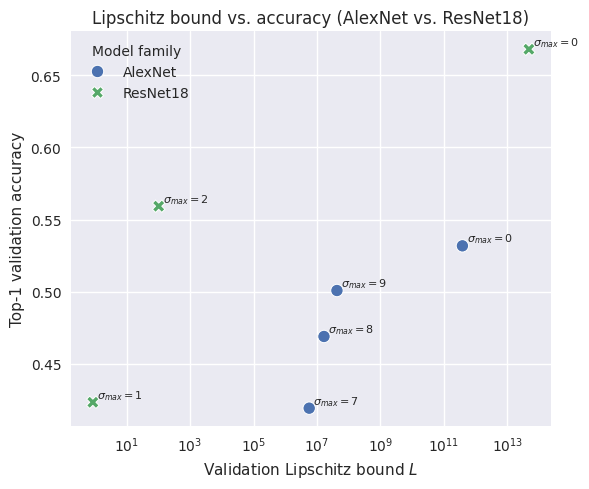

In [4]:
# Scatter plot: Lipschitz bound vs. accuracy

plot_df = metrics_df.dropna(subset=["val_accuracy", "val_lips_bound"]).copy()

fig, ax = plt.subplots(figsize=(6, 5))

sns.scatterplot(
    data=plot_df,
    x="val_lips_bound",
    y="val_accuracy",
    hue="family",
    style="family",
    s=80,
    ax=ax,
)

# Use log scale on x if bounds span more than an order of magnitude
if plot_df["val_lips_bound"].max() / plot_df["val_lips_bound"].min() > 10:
    ax.set_xscale("log")

for _, row in plot_df.iterrows():
    ax.annotate(
        f"$\\sigma_{{max}}={row['w_max']:g}$",
        (row["val_lips_bound"], row["val_accuracy"]),
        textcoords="offset points",
        xytext=(3, 3),
        fontsize=8,
    )

ax.set_xlabel("Validation Lipschitz bound $L$")
ax.set_ylabel("Top-1 validation accuracy")
ax.set_title("Lipschitz bound vs. accuracy (AlexNet vs. ResNet18)")
ax.legend(title="Model family")
plt.tight_layout()
plt.show()

## Metamer grids

The cells below load **locally saved metamers** for each model.

- Each row corresponds to a single trained model (specific config).
- Columns show the natural image followed by metamers from successive fake-ReLU layers (labels omit the `fake_relu` suffix).
- For each model, we pick **one random ImageNet example** (from the available metamer indices) and use the **same index across all layers** in that row.

In [ ]:
ALEXNET_FAKE_RELU_LAYERS = [
    "relu0_fake_relu",
    "relu1_fake_relu",
    "relu2_fake_relu",
    "relu3_fake_relu",
    "relu4_fake_relu",
    "fc0_relu_fake_relu",
    "fc1_relu_fake_relu",
    "final"
]

RESNET_FAKE_RELU_LAYERS = [
    "conv1_relu1_fake_relu",
    "layer1_fake_relu",
    "layer2_fake_relu",
    "layer3_fake_relu",
    "layer4_fake_relu",
    "avgpool",
    "final"
]


def layer_dir_for_config(cfg_path: str, layer_name: str) -> Path:
    exp_root = config_to_exp_root(cfg_path)
    return exp_root / "metamers" / layer_name


def available_indices_for_layer(layer_dir: Path) -> list[int]:
    meta = load_layer_metadata(layer_dir)
    return sorted(meta.keys())


def choose_shared_sample_idx_for_all(config_paths: list[str], layer_names: list[str]) -> int:
    """Choose one sample index present in all layers of all configs."""
    all_idx_sets = []
    for cfg_path in config_paths:
        idx_sets = []
        for layer in layer_names:
            layer_dir = layer_dir_for_config(cfg_path, layer)
            indices = available_indices_for_layer(layer_dir)
            if not indices:
                continue
            idx_sets.append(set(indices))
        if not idx_sets:
            raise RuntimeError(f"No metamer indices found for config {cfg_path}")
        shared = set.intersection(*idx_sets)
        if not shared:
            shared = idx_sets[0]
        all_idx_sets.append(shared)
    if not all_idx_sets:
        raise RuntimeError("No metamer indices found for any config")
    shared_among_all = set.intersection(*all_idx_sets)
    if not shared_among_all:
        # fallback: just use any from the first config
        shared_among_all = all_idx_sets[0]
    return random.choice(sorted(shared_among_all))


def find_image_path(layer_dir: Path, sample_idx: int, kind: str) -> Path:
    """Find metamer or original PNG for a given sample index.

    kind: "metamer" or "original".
    """
    pattern = f"idx{sample_idx:04d}_*_{kind}.png"
    matches = sorted(layer_dir.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"No {kind} image found in {layer_dir} for sample {sample_idx}")
    return matches[0]


def _clean_layer_label(layer_name: str) -> str:
    return layer_name.replace("_fake_relu", "").replace("_fakerelu", "")


def plot_metamer_grid(config_paths: list[str], layer_names: list[str], title: str):
    n_rows = len(config_paths)
    n_cols = 1 + len(layer_names)

    # Add extra width to the figure to allow space for row labels
    # Widen first column; set width_ratios to make the first (labels) column ~2x wider
    width_ratios = [1.35] + [1.0] * (n_cols - 1)
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(2.3 * n_cols, 2.0 * n_rows),
        gridspec_kw={'width_ratios': width_ratios}
    )
    if n_rows == 1:
        axes = axes[None, :]

    # Always use the same sample_idx for every model
    sample_idx = choose_shared_sample_idx_for_all(config_paths, layer_names)

    for row, cfg_path in enumerate(config_paths):
        _, label, _ = clean_model_label(cfg_path)

        # First column: natural image from first layer directory
        first_layer_dir = layer_dir_for_config(cfg_path, layer_names[0])
        orig_path = find_image_path(first_layer_dir, sample_idx, "original")
        orig_img = plt.imread(orig_path)
        ax = axes[row, 0]
        ax.imshow(orig_img)
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title("natural image")
        ax.set_ylabel(
            label,
            fontsize=10,
            rotation=0,
            labelpad=55,   # Increased label pad for more space
            va="center"
        )

        # Metamers
        for col, layer_name in enumerate(layer_names, start=1):
            layer_dir = layer_dir_for_config(cfg_path, layer_name)
            met_path = find_image_path(layer_dir, sample_idx, "metamer")
            met_img = plt.imread(met_path)
            ax = axes[row, col]
            ax.imshow(met_img)
            ax.set_xticks([])
            ax.set_yticks([])
            if row == 0:
                ax.set_title(_clean_layer_label(layer_name))

    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()

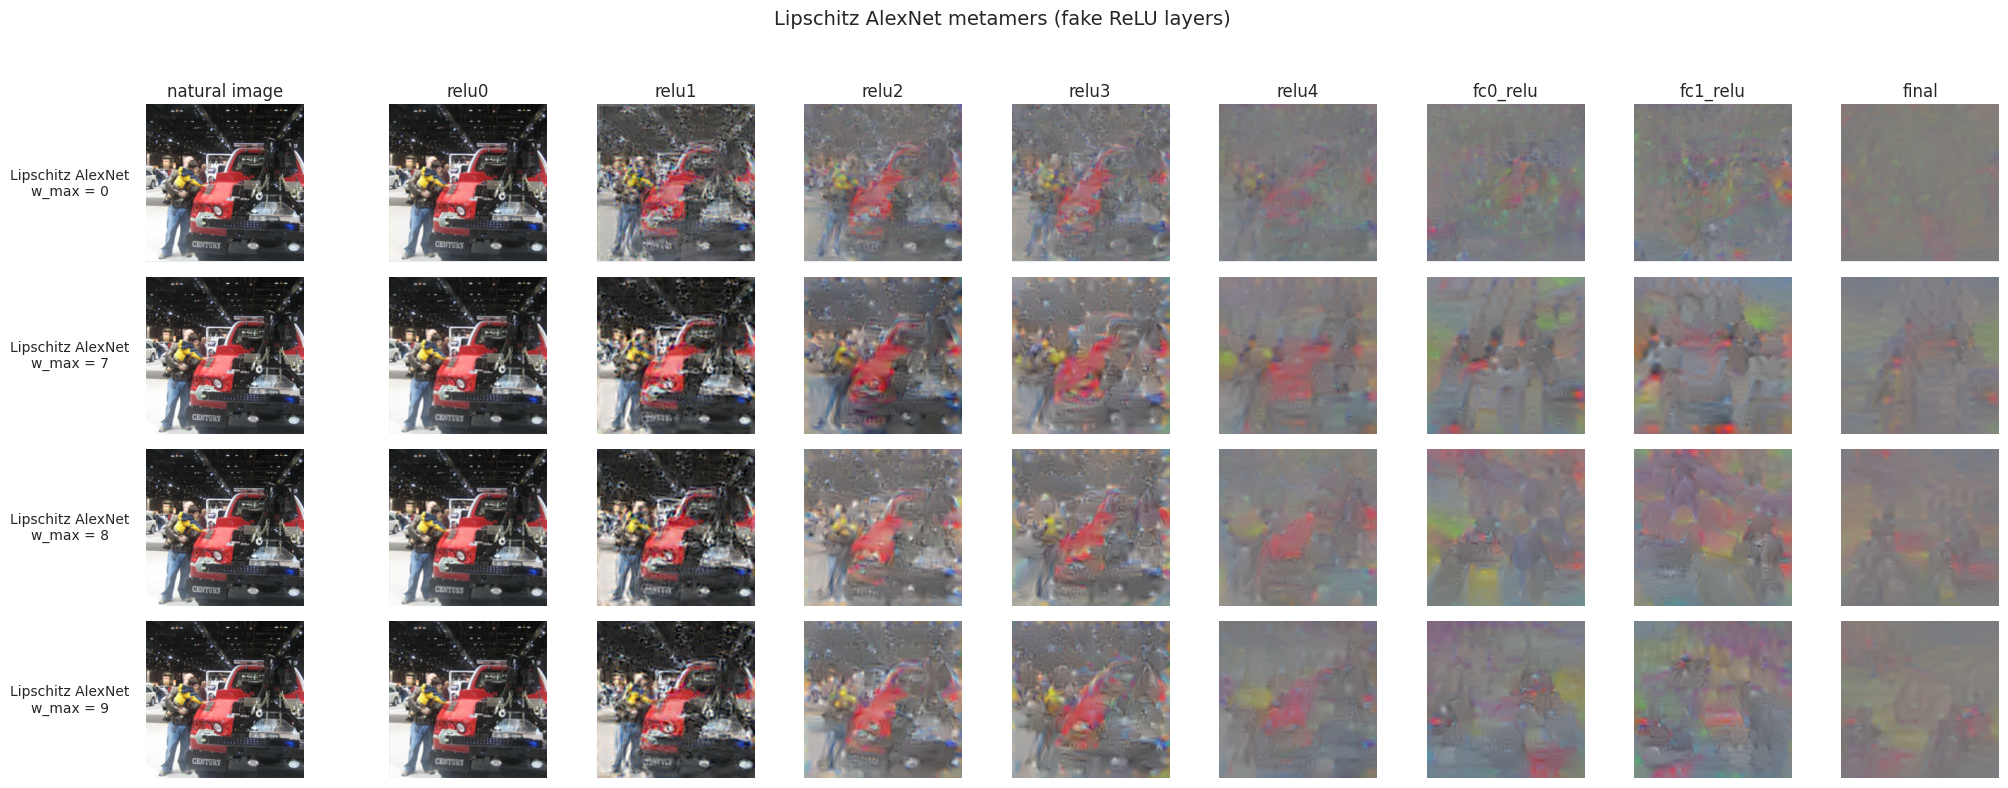

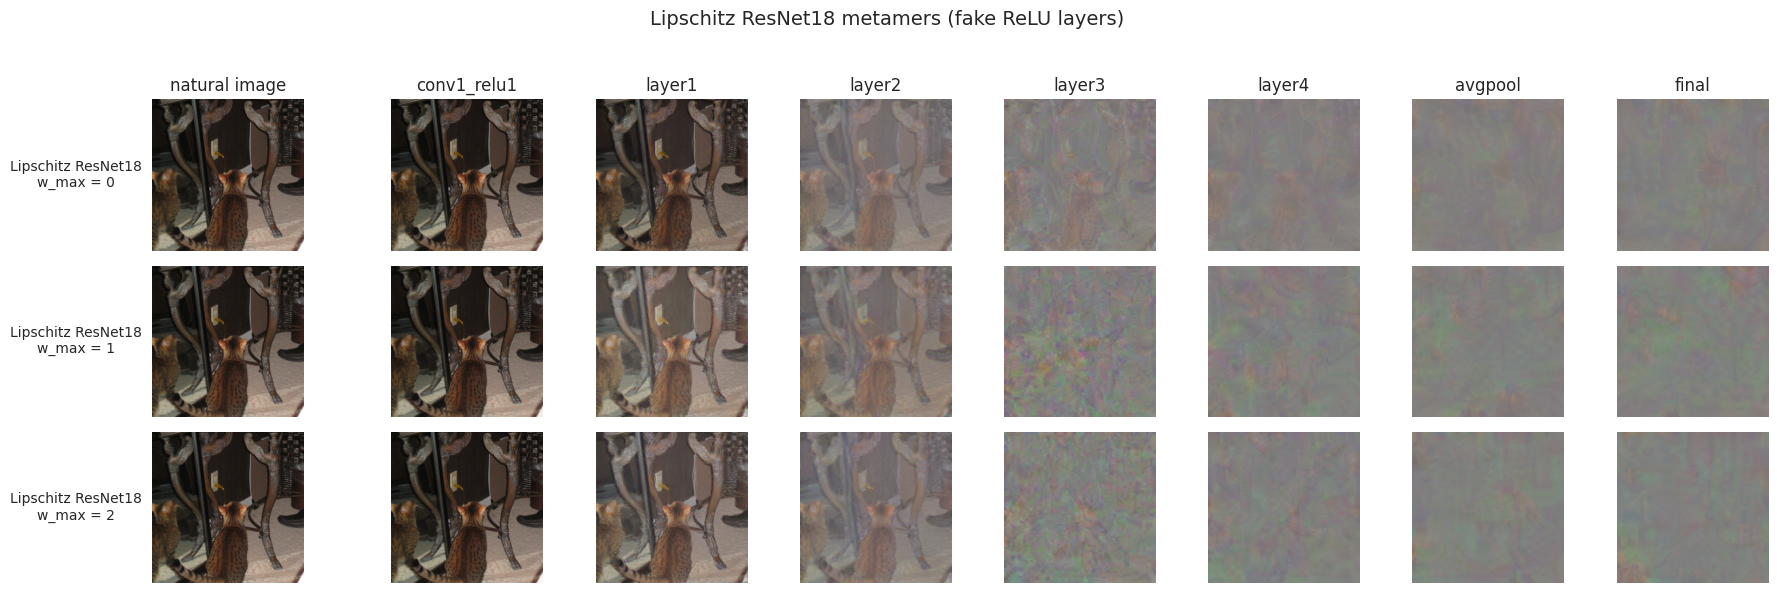

In [7]:
# AlexNet metamer grid (rows = configs, columns = layers)

plot_metamer_grid(
    config_paths=ALEXNET_CONFIGS,
    layer_names=ALEXNET_FAKE_RELU_LAYERS,
    title="Lipschitz AlexNet metamers (fake ReLU layers)",
)

# ResNet metamer grid

plot_metamer_grid(
    config_paths=RESNET_CONFIGS,
    layer_names=RESNET_FAKE_RELU_LAYERS,
    title="Lipschitz ResNet18 metamers (fake ReLU layers)",
)